In [2]:
import pandas as pd
import geopandas as gpd
import numpy as np
from sklearn.metrics import pairwise_distances
from pymoo.core.problem import Problem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize
import matplotlib.pyplot as plt
import plotly.graph_objects as go

In [ ]:
# CARGA DE DATOS

gdf_nodos = gpd.read_file("dataset_final.gpkg")

# Asegurar CRS métrico (EPSG:3857)
if gdf_nodos.crs is None:
    gdf_nodos = gdf_nodos.set_crs(epsg=4326) # sistema de latitud y longitud (?)
if gdf_nodos.crs.to_epsg() != 3857:
    gdf_nodos = gdf_nodos.to_crs(epsg=3857)

# Convertir a puntos si hay polígonos o líneas (se necesita la informacion de los puntos no de lineas)
geom_types = gdf_nodos.geometry.geom_type.unique()
if not np.all(np.isin(geom_types, ["Point", "MultiPoint"])):
    gdf_nodos = gdf_nodos.copy()
    gdf_nodos["geometry"] = gdf_nodos.geometry.centroid

gdf = gdf_nodos

In [ ]:
# FUNCIONES DE FITNESS

def fitness_cantidad_estaciones(estaciones_osmid, factor=1.0):   # No se esta usando

    return np.float64(len(estaciones_osmid) * factor) # Retorna cant de estaciones * factor de relevancia


def fitness_prioridad_simple(gdf, estaciones_osmid, peso_flujo=0.7, peso_esquinas=0.3): # pesan el flujo y la cantidad de esqunas de una zona

    flujo_norm = gdf['flujo_total'] / (gdf['flujo_total'].max() + 1e-6) # Normalización del flujo de trafico
    esquinas_norm = gdf['esquinas_en_radio'] / (gdf['esquinas_en_radio'].max() + 1e-6) # Normalización de cantidad de esquinas
    gdf['prioridad'] = peso_flujo * flujo_norm + peso_esquinas * esquinas_norm # Cálculo de prioridad del nodo
    prioridades = gdf.loc[gdf['osmid'].isin(estaciones_osmid), 'prioridad'] # Almacenamiento
    return np.float64(prioridades.mean() if len(prioridades) > 0 else 0.0) # Retorna como fitness la media de prioridad de todas las estaciones del individuo


def fitness_cobertura_global(gdf_nodos, estaciones_idx, d_max=50000, penalizacion=1e6):
  
    # Extraer coordenadas
    coords = np.vstack((gdf_nodos.geometry.x, gdf_nodos.geometry.y)).T
    estaciones = coords[np.array(estaciones_idx)]

    # Calcular distancias nodo a estación (usando la distancia euclidea se clacula la de distancia minima)
    dist_matrix = pairwise_distances(coords, estaciones, metric='euclidean')
    dist_min = dist_matrix.min(axis=1)

    # Penalizar los que superan d_max
    penalizadas = dist_min.copy()
    penalizadas[penalizadas > d_max] += penalizacion # (para las que son mayores a las penalizadas guarda ese valor mas la penalizacion)

    # Se toma la distancia máxima que se obtuvo (la peor distancia cubierta, para saber que tan malo es para cubrir cierta distancia)
    return float(penalizadas.max())

In [ ]:
# DEFINICION DEL PROBLEMA (CLASE QUE LUEGO SE UTILIZA EN NSGA-2)
# Minimiza: cantidad de estaciones, distancia máxima, prioridad invertida

class EVChargingProblem3F(Problem):
    def __init__(self, gdf, d_max,
                 factor_estaciones=5.0,          # factor de penalización relativo
                 max_ratio=0.15,                 # máximo permitido de estaciones (% del total de nodos)
                 peso_flujo=0.7, peso_esquinas=0.3,
                 penalizacion=10, debug=False):

        self.gdf = gdf.copy() # dataframe de nodos
        self.d_max = d_max
        self.factor_estaciones = factor_estaciones # factor para ponderar la cantidad de estaciones en el fitness
        self.max_ratio = max_ratio # maximo porcentaje de nodos que pueden ser estaciones
        self.peso_flujo = peso_flujo
        self.peso_esquinas = peso_esquinas
        self.penalizacion = penalizacion
        self.debug = debug
        self.n_nodos = len(gdf)
        super().__init__(n_var=self.n_nodos, n_obj=3, xl=0, xu=1, type_var=int)

    #Funcion que reune todas las funciones de fitness y retorna el elemento utilizado en NSGA-2 para minimize
    def _evaluate(self, X, out, *args, **kwargs):
        f1_raw = np.zeros(len(X))
        f2_raw = np.zeros(len(X))
        f3_raw = np.zeros(len(X))

        max_estaciones = int(self.n_nodos * self.max_ratio)

        for i, individuo in enumerate(X):   # para cada individuo
            individuo = np.round(individuo).astype(int)
            estaciones_idx = np.where(individuo == 1)[0]
            estaciones_osmid = self.gdf["osmid"].iloc[estaciones_idx].tolist()
            n_est = len(estaciones_osmid)

            # --- Objetivo 1: cantidad de estaciones (normalizado y penalizado) ---
            exceso = max(0, n_est - max_estaciones) # exceso de estaciones sobre el máximo permitido 
            penalizacion_exceso = exceso * 5.0  # castigo adicional (ajustable)  # penaliza 5 unidades por cada estación que exceda el máximo permitido
            f1_raw[i] = (n_est / self.n_nodos) * self.factor_estaciones + penalizacion_exceso

            # --- Objetivo 2: cobertura global (distancia máxima) ---
            f2_raw[i] = fitness_cobertura_global(
                self.gdf, estaciones_idx,
                d_max=self.d_max,
                penalizacion=self.penalizacion)

            # --- Objetivo 3: prioridad (flujo + esquinas, invertido) ---
            f3_raw[i] = 1 - fitness_prioridad_simple(
                self.gdf, estaciones_osmid,
                peso_flujo=self.peso_flujo,
                peso_esquinas=self.peso_esquinas
            )

        # Retorna la salida a la que accede minimize luego
        out["F"] = np.column_stack([
            f1_raw,              # penaliza cantidad de estaciones (ya está normalizado)
            f2_raw / self.d_max, # distancia máxima relativa (0–1)
            f3_raw               # prioridad invertida (0–1)
        ])


In [ ]:
# EJECUCIÓN DEL MODELO NSGA-2

n_nodos = len(gdf)

# Variables modificables
d_max = 10000 # Distancia max que se tolera entre un nodo y la estacion de carga mas cercana
pop_size = 200 #  Cantidad de la poblacion (cant individuos por generacion)
n_gen = 500
factor_est = 50 # Importancia que se le de a la minimizacion de estaciones de carga (factor)


# Generar población inicial aleatoria
X_init = np.random.randint(0, 2, size=(pop_size, n_nodos))

algorithm = NSGA2(pop_size=pop_size, eliminate_duplicates=True) # genera los parametros del algoritmo para minimizar (?)

#Funcion que se encarga de encontrar la FRONTERA DE PARETO (SOLUCIONES NO DOMINADAS, es decir sol que no se pueden minimizar un parametro sin empeorar otro)
res = minimize( # la soluciones no dominadas mantienen la relacion entre los valores de fitness
    EVChargingProblem3F(gdf, d_max=d_max, factor_estaciones=factor_est),
    algorithm,
    ('n_gen', n_gen),
    seed=23,
    verbose=True,
    save_history=True,
    X=X_init
)

#SE GUARDA EL RESULTADO
np.savez("resultado_nsga2_final.npz", X=res.X, F=res.F)

print("✅ Arrays X y F guardados en 'resultado_nsga2.npz'")

# n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
#                             Mejoria por iteracion

n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |      200 |     11 |             - |             -
     2 |      400 |     25 |  0.2200000000 |         ideal
     3 |      600 |     26 |  0.1062664256 |         ideal
     4 |      800 |     30 |  0.1186039546 |         nadir
     5 |     1000 |     39 |  0.0184122794 |         ideal
     6 |     1200 |     45 |  0.1827084405 |         ideal
     7 |     1400 |     39 |  0.0852451268 |         ideal
     8 |     1600 |     40 |  0.0303030303 |         ideal
     9 |     1800 |     44 |  0.1750000000 |         ideal
    10 |     2000 |     59 |  0.0407518864 |         ideal
    11 |     2200 |     61 |  0.1532496268 |         ideal
    12 |     2400 |     61 |  0.0454545455 |         ideal
    13 |     2600 |     46 |  0.0293213996 |             f
    14 |     2800 |     45 |  0.0468179747 |         ideal
    15 |     3000 |     59 |  0.0902803527 |         ideal
    16 |     3200 |     62 |  0.0292519850 |            

In [ ]:
# IMPRIMIR RESULTADOS DE OPTIMIZACION 

print("Frontera de Pareto (f1: estaciones, f2: distancia, f3: calidad invertida):")
print(res.F)

# Valores de las funciones de fitness
# (Frontera de pareeto)

Frontera de Pareto (f1: estaciones, f2: distancia, f3: calidad invertida):
[[  4.91803279   1.001        0.5278803 ]
 [  5.73770492   1.001        0.50350787]
 [216.68032787   0.40005181   0.66492649]
 [  4.91803279   1.001        0.5278803 ]
 [ 63.60655738   0.47925724   0.69927637]
 [231.98770492   0.40905183   0.65538621]
 [  6.35245902   0.91961134   0.52754708]
 [  5.73770492   0.92711446   0.54421175]
 [  6.35245902   0.84679351   0.53199548]
 [  6.76229508   0.791681     0.56434982]
 [  6.65983607   0.75063534   0.5689708 ]
 [119.73360656   0.41378669   0.69356834]
 [145.24590164   0.49376593   0.63523477]
 [165.6557377    0.43989964   0.63872218]
 [ 32.99180328   0.69375924   0.58275308]
 [ 99.32377049   0.45561211   0.65607248]
 [ 89.11885246   0.47416057   0.68067762]
 [ 53.40163934   0.53286664   0.62889222]
 [191.16803279   0.40127172   0.66959523]
 [ 12.58196721   0.71621562   0.57682809]
 [ 38.0942623    0.61047389   0.60034953]
 [ 17.68442623   0.5954936    0.6146865 ]
 

In [8]:
# GRAFICAR FRONTERA DE PARETO (IMPORTANTE LA GRAFICA)

F = np.array(res.F)  # Asegurarse de que esté en formato numpy array

# Crear figura 3D interactiva
fig = go.Figure(data=[go.Scatter3d(
    x=F[:, 0],  # f1
    y=F[:, 1],  # f2
    z=F[:, 2],  # f3
    mode='markers',
    marker=dict(
        size=6,
        color=F[:, 2],          # color según calidad invertida
        colorscale='Viridis',   # escala de color bonita
        opacity=0.9,
        colorbar=dict(title="Calidad invertida")
    ),
    text=[f"Estaciones: {f1:.3f}<br>Distancia: {f2:.3f}<br>Calidad Inv: {f3:.3f}"
          for f1, f2, f3 in F],
    hoverinfo='text'
)])

# Configurar layout del gráfico
fig.update_layout(
    title="🌈 Frente de Pareto 3D — Estaciones vs Distancia vs Calidad",
    scene=dict(
        xaxis_title="f1: Estaciones (normalizado)",
        yaxis_title="f2: Distancia (normalizada)",
        zaxis_title="f3: Calidad invertida",
    ),
    width=900,
    height=700,
)

fig.show()

In [ ]:
# VALIDACION DE RESULTADOS

def validar_soluciones(problem, X, F, gdf):
    resultados = []
    coords = np.vstack((gdf.geometry.x, gdf.geometry.y)).T
    n_nodos = len(gdf)
    
    for i in range(len(X)):
        individuo = np.round(X[i]).astype(int)
        estaciones_idx = np.where(individuo == 1)[0]
        estaciones_osmid = gdf.iloc[estaciones_idx]["osmid"].tolist()
        
        # --- Métricas reales --- #(desnormaliza los valores de f1, f2 y f3)
        num_estaciones = int(np.sum(individuo))
        prioridad_media = 1 - F[i, 2]  # revertimos inversión
        f2_max_real = (F[i,1] * problem.d_max)  # distancia máxima real (metros)
        
        # Distancias nodo-estación
        if len(estaciones_idx) > 0:
            dist_matrix = pairwise_distances(coords, coords[estaciones_idx], metric='euclidean')
            dist_min = dist_matrix.min(axis=1)
        else:
            dist_min = np.full(n_nodos, problem.d_max + problem.penalizacion)
        
        cobertura_promedio = dist_min.mean()
        porcentaje_cubiertos = np.sum(dist_min <= problem.d_max) / n_nodos * 100
        eficiencia = porcentaje_cubiertos / max(1, num_estaciones)
        
        resultados.append({
            "indice": i,
            "num_estaciones": num_estaciones,
            "distancia_max": f2_max_real,
            "cobertura_promedio": cobertura_promedio,
            "prioridad_media": prioridad_media,
            "%_nodos_cubiertos": porcentaje_cubiertos,
            "eficiencia": eficiencia,
            "estaciones_osmid": estaciones_osmid
        })
    
    df_validacion = pd.DataFrame(resultados)
    return df_validacion

df_validacion = validar_soluciones(
    problem=EVChargingProblem3F(gdf, d_max=d_max, factor_estaciones=factor_est),
    X=res.X,
    F=res.F,
    gdf=gdf)

print(df_validacion.sort_values("eficiencia", ascending=False).head(5))

     indice  num_estaciones  distancia_max  cobertura_promedio  \
0         0              48   10010.000000         3750.466286   
3         3              48   10010.000000         3750.466286   
163     163              53    8467.935114         3019.548542   
75       75              50   10010.000000         3724.562058   
199     199              55    9271.144610         2976.171029   

     prioridad_media  %_nodos_cubiertos  eficiencia  \
0           0.472120          92.418033    1.925376   
3           0.472120          92.418033    1.925376   
163         0.425391         100.000000    1.886792   
75          0.476602          92.418033    1.848361   
199         0.448713         100.000000    1.818182   

                                      estaciones_osmid  
0    [12662819184, 90953136, 11746003366, 90907979,...  
3    [12662819184, 90953136, 11746003366, 90907979,...  
163  [12662819184, 90953136, 11746003366, 90907979,...  
75   [12662819184, 90953136, 11746003366, 90

=== 3 Soluciones con menor cantidad de estaciones ===
    indice  num_estaciones  distancia_max_km  prioridad_media
0        0              48             10.01         0.472120
3        3              48             10.01         0.472120
75      75              50             10.01         0.476602


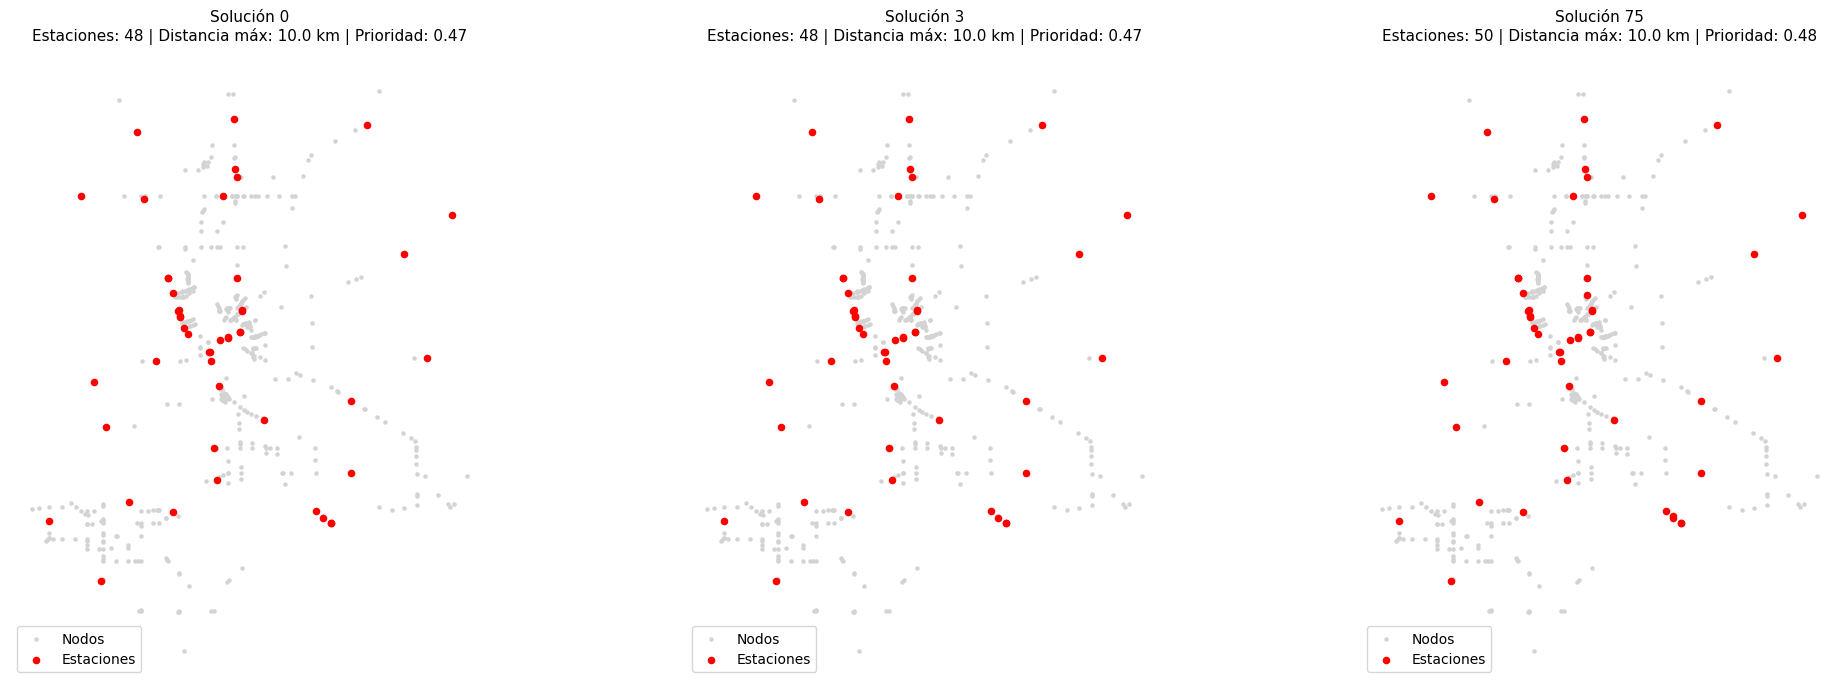

In [10]:
def interpretar_y_graficar_mejores(problem, X, F, gdf, n_mejores=3):

#SE ELIGEN LAS 3 SOLUCIONES QUE MENOR CANTIDAD DE ESTACIONES DE CARGA TIENEN, Y SE RETORNAN SUS RESULTADOS Y SE GRAFICAN

    resultados = []

    for i in range(len(X)):
        individuo = np.round(X[i]).astype(int)
        estaciones_idx = np.where(individuo == 1)[0]
        estaciones_osmid = gdf.iloc[estaciones_idx]["osmid"].tolist()

        # DESNORMALIZO VALORES (ES LO UNICO IMPORTANTE DE ESTA FUNCION)
        num_estaciones = int(np.sum(individuo))
        dist_max_km = (F[i, 1] * problem.d_max) / 1000           # distancia máxima en km
        prioridad_media = 1 - F[i, 2]                             # revertimos la inversión

        resultados.append({
            "indice": i,
            "num_estaciones": num_estaciones,
            "distancia_max_km": dist_max_km,
            "prioridad_media": prioridad_media,
            "estaciones_osmid": estaciones_osmid
        })

    df_resultados = gpd.pd.DataFrame(resultados)

    # Seleccionar las n_mejores soluciones con menor cantidad de estaciones
    df_mejores = df_resultados.sort_values("num_estaciones").head(n_mejores)

    print(f"=== {n_mejores} Soluciones con menor cantidad de estaciones ===")
    print(df_mejores[["indice", "num_estaciones", "distancia_max_km", "prioridad_media"]])

    # Graficar
    fig, axes = plt.subplots(1, n_mejores, figsize=(7 * n_mejores, 7))
    if n_mejores == 1:
        axes = [axes]

    for ax, (_, fila) in zip(axes, df_mejores.iterrows()):
        gdf_plot = gdf.copy()
        gdf_plot["estacion"] = gdf_plot["osmid"].isin(fila["estaciones_osmid"])

        gdf_plot.plot(ax=ax, color="lightgray", markersize=5, label="Nodos")
        gdf_plot[gdf_plot["estacion"]].plot(ax=ax, color="red", markersize=20, label="Estaciones")

        ax.set_title(
            f"Solución {fila['indice']}\n"
            f"Estaciones: {fila['num_estaciones']} | "
            f"Distancia máx: {fila['distancia_max_km']:.1f} km | "
            f"Prioridad: {fila['prioridad_media']:.2f}",
            fontsize=11
        )
        ax.legend()
        ax.axis("off")

    plt.tight_layout()
    plt.show()

    return df_mejores

df_mejores = interpretar_y_graficar_mejores(EVChargingProblem3F(gdf, d_max=d_max, factor_estaciones=factor_est), res.X, res.F, gdf, n_mejores=3)